# Data exploration
Data exploratin of the final dataset: 
- day, pos, number of vessel, bgc variables 

# Set

In [1]:
import numpy as np
import pandas as pd
import sklearn

print("Notebook AIPS check")
print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)

Notebook AIPS check
2.2.6
2.3.3
1.7.2


In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
YEAR = 2024

raw = "data/raw/"
interim_folder = "data/interim/"
processed_folder = "data/processed/"

cpr_gfw_dp_name = f"cpr_gfw_{YEAR}_from_notebook.parquet"
ais_dp_name = f"cleaned_ais_high_daily_ts_{YEAR}.parquet"
s2_dp_name = f"cleaned_s2_vessel_detections_{YEAR}.parquet"
gulf_coords_dp_name = "ts_gulf_coords.csv"

# Import 

In [9]:
cpr_gfw = pd.read_parquet(f"{processed_folder}{cpr_gfw_dp_name}")
ais = pd.read_parquet(f"{interim_folder}{ais_dp_name}")
sar = pd.read_parquet(f"{interim_folder}{s2_dp_name}")

gulf_coords = pd.read_csv(f"{raw}{gulf_coords_dp_name}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/cpr_gfw_2024_from_notebook.parquet'

# Trawlers vs other - spatial analysis 

In [5]:
sar_unq_coords = sar[['latitude', 'longitude']].drop_duplicates()
ais_unq_coords = ais[['latitude', 'longitude']].drop_duplicates()

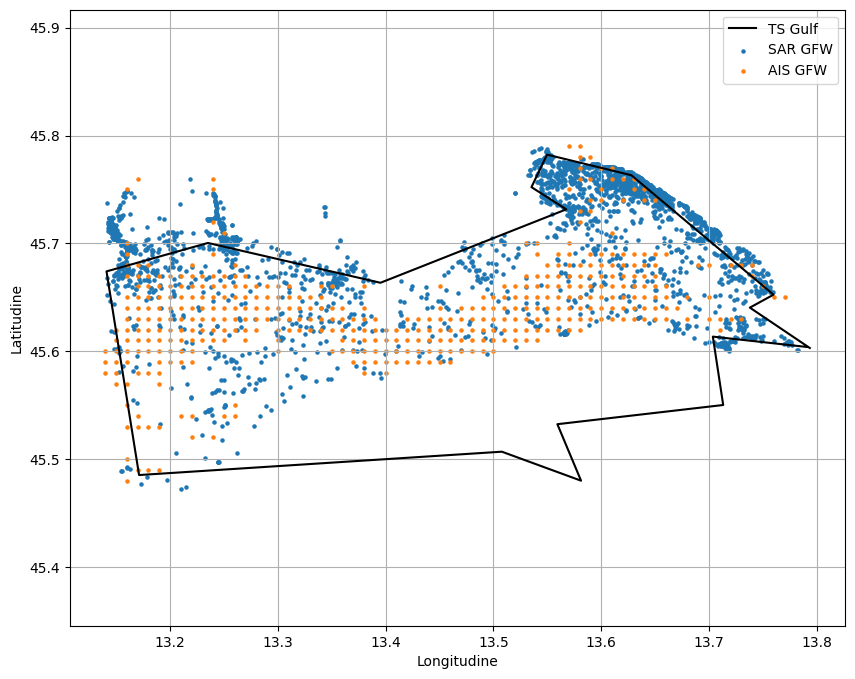

In [6]:
plt.figure(figsize=(10,8))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(sar_unq_coords['longitude'], sar_unq_coords['latitude'], label = 'SAR GFW', s = 5)
plt.scatter(ais_unq_coords['longitude'], ais_unq_coords['latitude'], label = 'AIS GFW', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [7]:
trawlers_condition = ais['gear_type'] == 'TRAWLERS'
pots_and_traps_condition = ais['gear_type'] == 'POTS_AND_TRAPS'
dredge_fishing_condition = ais['gear_type'] == 'DREDGE_FISHING'
other_purse_seines_condition = ais['gear_type'] == 'OTHER_PURSE_SEINES'
fishing_condition = ais['gear_type'] == 'FISHING'   

ais_trawlers = ais[trawlers_condition].copy()
ais_n_trawlers = ais[~trawlers_condition].copy()
ais_pots_and_traps = ais[pots_and_traps_condition].copy()
ais_dredge_fishing = ais[dredge_fishing_condition].copy()
ais_other_purse_seines = ais[other_purse_seines_condition].copy()
ais_fishing = ais[fishing_condition].copy()


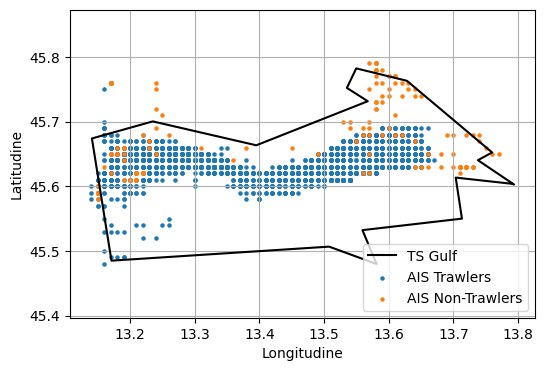

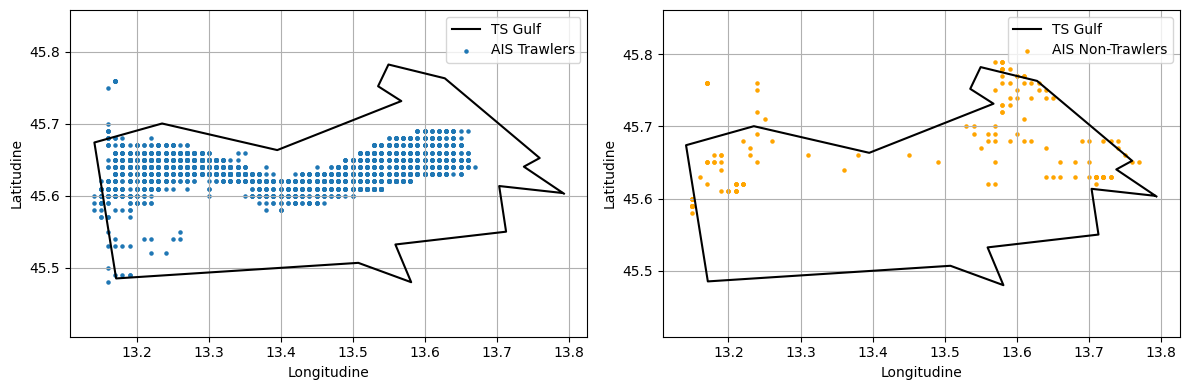

In [8]:
plt.figure(figsize=(6,4))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], label = 'AIS Non-Trawlers', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Primo subplot: Trawlers ---
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()

# --- Secondo subplot: Non-Trawlers ---
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_n_trawlers['longitude'], ais_n_trawlers['latitude'], s=5, color='orange', label='AIS Non-Trawlers')
axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


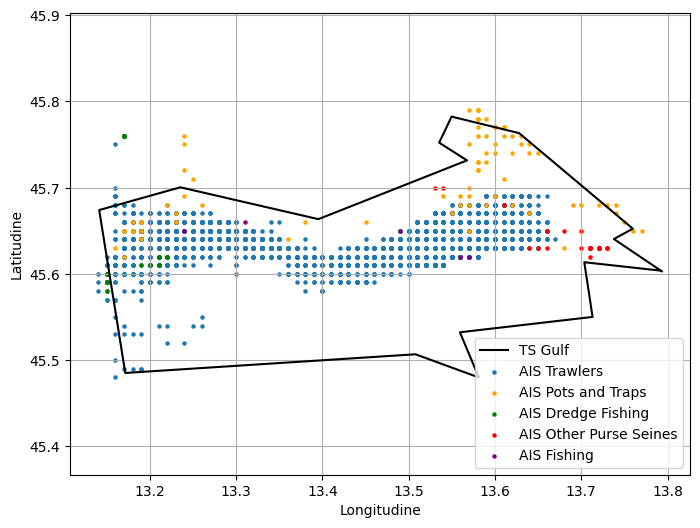

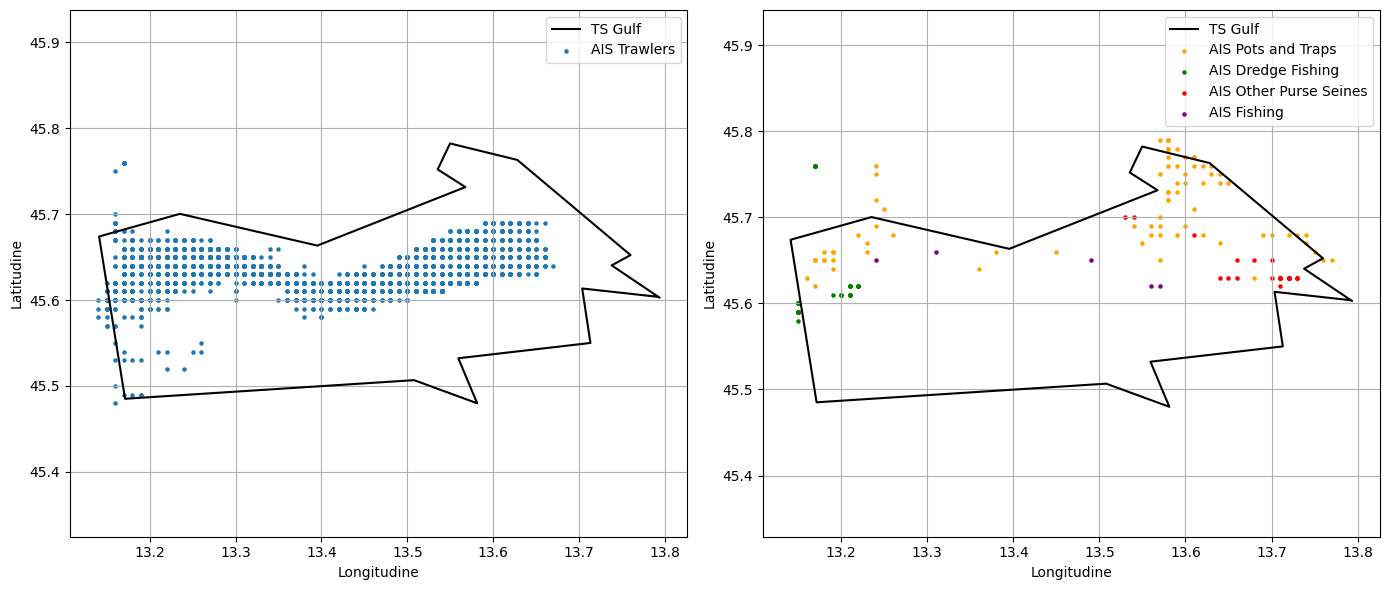

In [9]:
plt.figure(figsize=(8,6))

plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], label = 'AIS Trawlers', s = 5)
plt.scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], label = 'AIS Pots and Traps', s = 5, color = 'orange')
plt.scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], label = 'AIS Dredge Fishing', s = 5, color = 'green')
plt.scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], label = 'AIS Other Purse Seines', s = 5, color = 'red')
plt.scatter(ais_fishing['longitude'], ais_fishing['latitude'], label = 'AIS Fishing', s = 5, color = 'purple')
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')

axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')

axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()


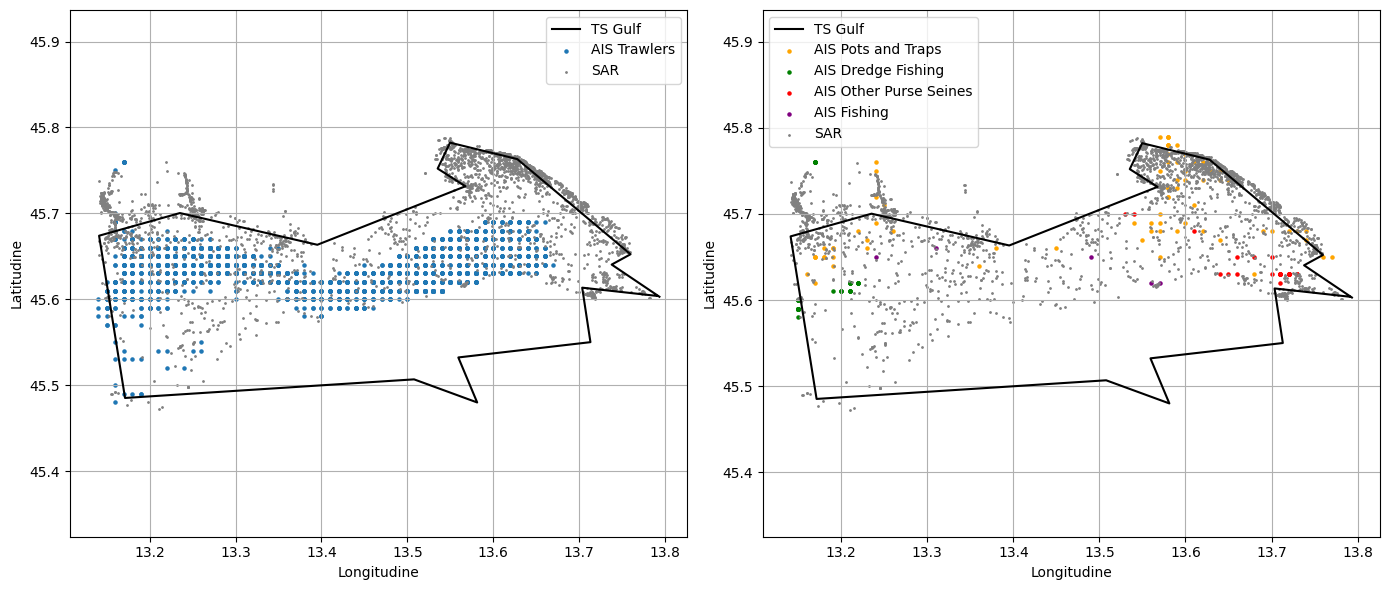

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------------
# SUBPLOT 1 — AIS Trawlers
# -------------------------------
axes[0].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[0].scatter(ais_trawlers['longitude'], ais_trawlers['latitude'], s=5, label='AIS Trawlers')
axes[0].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[0].set_xlim(13, 14)
axes[0].set_ylim(45.3, 45.9)
axes[0].set_xlabel("Longitudine")
axes[0].set_ylabel("Latitudine")
axes[0].grid(True)
axes[0].axis("equal")
axes[0].legend()


# -------------------------------
# SUBPLOT 2 — Altri attrezzi (Pots, Dredge, Purse Seines, Fishing)
# -------------------------------
axes[1].plot(gulf_coords['longitude'], gulf_coords['latitude'], color='black', label='TS Gulf')
axes[1].scatter(ais_pots_and_traps['longitude'], ais_pots_and_traps['latitude'], s=5, label='AIS Pots and Traps', color='orange')
axes[1].scatter(ais_dredge_fishing['longitude'], ais_dredge_fishing['latitude'], s=5, label='AIS Dredge Fishing', color='green')
axes[1].scatter(ais_other_purse_seines['longitude'], ais_other_purse_seines['latitude'], s=5, label='AIS Other Purse Seines', color='red')
axes[1].scatter(ais_fishing['longitude'], ais_fishing['latitude'], s=5, label='AIS Fishing', color='purple')
axes[1].scatter(sar['longitude'], sar['latitude'], s=1, label='SAR', color = 'grey')

axes[1].set_xlim(13, 14)
axes[1].set_ylim(45.3, 45.9)
axes[1].set_xlabel("Longitudine")
axes[1].set_ylabel("Latitudine")
axes[1].grid(True)
axes[1].axis("equal")
axes[1].legend()


plt.tight_layout()
plt.show()

# Marine variables - spatial analysis 

In [11]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.432612,13.304394,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,False,None,False,False,45.479168,13.166667,0.409951,13.248711,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,False,None,False,False,45.479168,13.166667,0.387921,13.063446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,False,None,False,False,45.479168,13.166667,0.367288,12.772483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,False,None,False,False,45.479168,13.166667,0.347252,13.004619,0.0,0.0,0.0,0.0,0.0,0.0,0.0


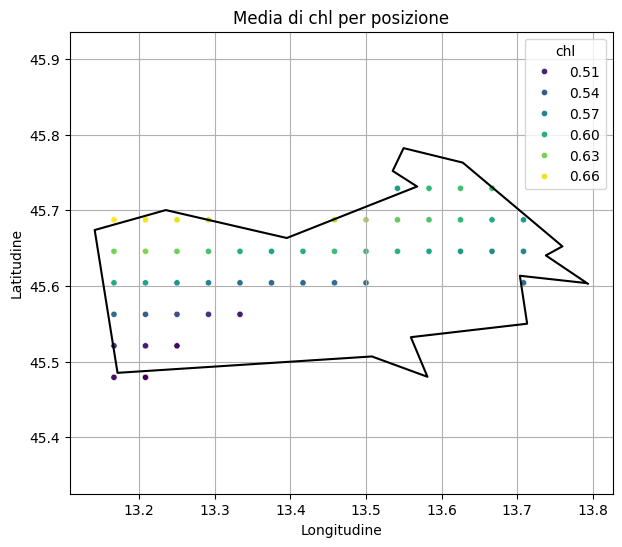

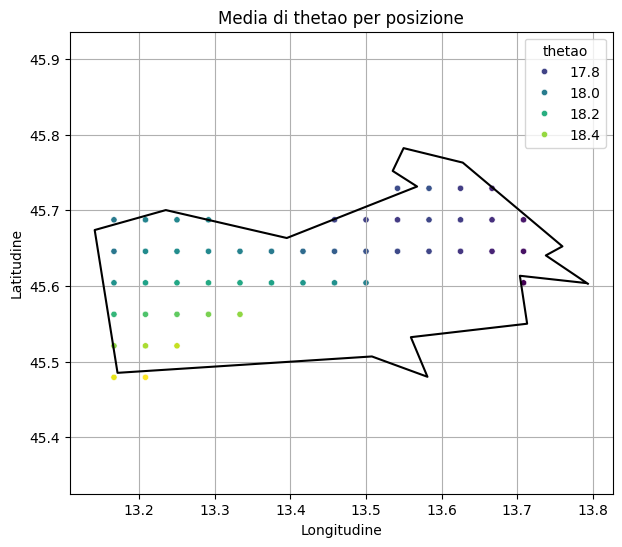

In [12]:
bgc_var_names = ['chl', 'thetao']  # chl, thetao

for bgc_var_name in bgc_var_names:
    df_pos = cpr_gfw.groupby(["latitude", "longitude"], as_index=False)[bgc_var_name].mean()

    plt.figure(figsize=(7, 6))
    
    sns.scatterplot(
        data=df_pos,
        x="longitude",
        y="latitude",
        hue=bgc_var_name,
        palette="viridis",
        s=20
    )
    plt.plot(gulf_coords['longitude'], gulf_coords['latitude'], color = 'black')
    
    plt.xlabel("Longitudine")
    plt.ylabel("Latitudine")
    plt.title(f"Media di {bgc_var_name} per posizione")
    plt.axis("equal")
    plt.grid(True)
    
    plt.show()


# Marine variables - temporal analysis 

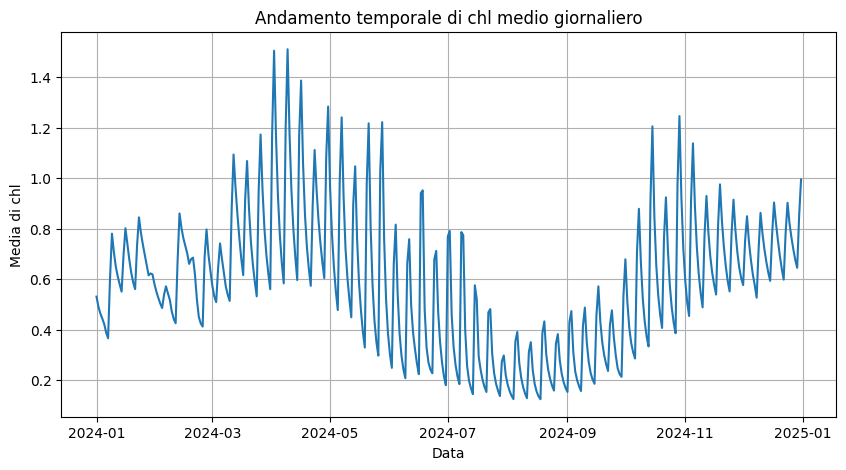

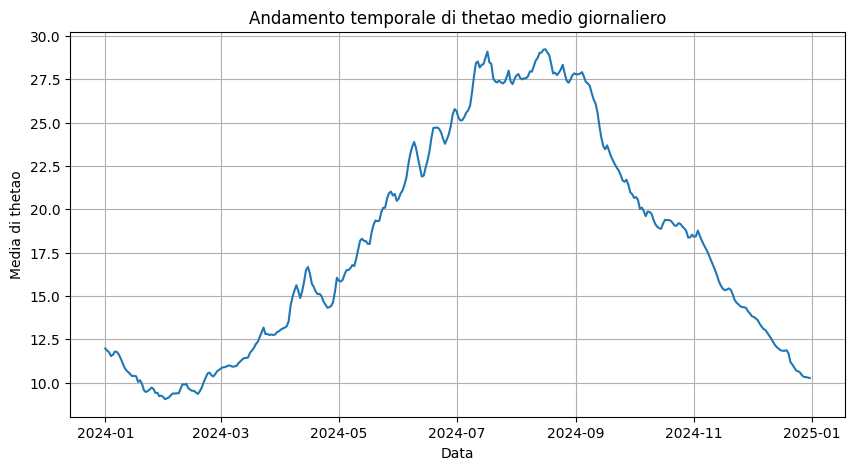

In [13]:
bgc_var_names = ['chl', 'thetao']  # chl, thetao

for bgc_var_name in bgc_var_names:
    df_bgc = cpr_gfw.groupby('date', as_index=False)[bgc_var_name].mean()
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_bgc['date'], df_bgc[bgc_var_name])
    plt.xlabel('Data')
    plt.ylabel(f'Media di {bgc_var_name}')
    plt.title(f'Andamento temporale di {bgc_var_name} medio giornaliero')
    plt.grid(True)
    plt.show()

# Gears - temporal analysis 

In [14]:
cpr_gfw.columns

Index(['date', 'is_holiday', 'holiday_name', 'is_weekend', 'fishing_block',
       'latitude', 'longitude', 'chl', 'thetao', 'sar_vessels_count',
       'ais_vessels_count', 'DREDGE_FISHING', 'FISHING', 'OTHER_PURSE_SEINES',
       'POTS_AND_TRAPS', 'TRAWLERS'],
      dtype='object')

In [15]:
import numpy as np

# Riassumo per data le info di weekend/festivo (max va bene per bool)
date_flags = (
    cpr_gfw
    .groupby('date', as_index=False)[['is_weekend', 'is_holiday']]
    .max()
)


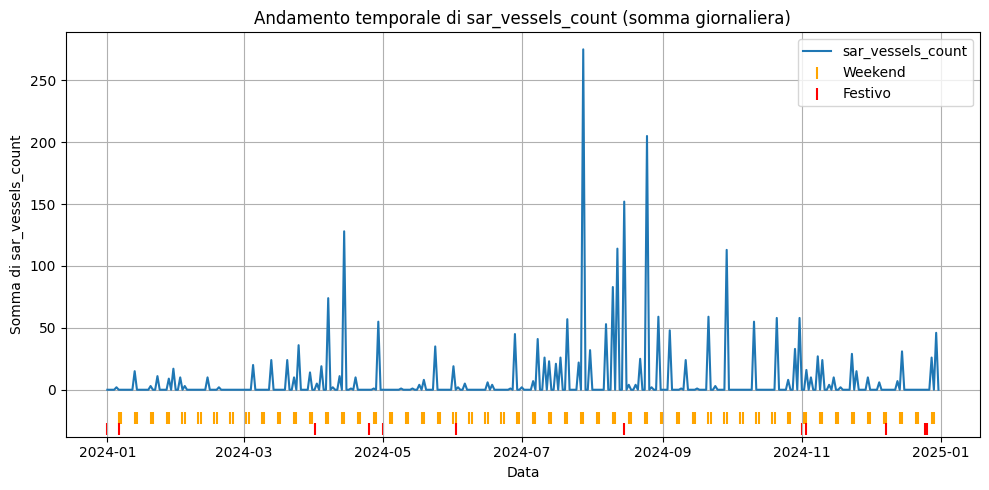

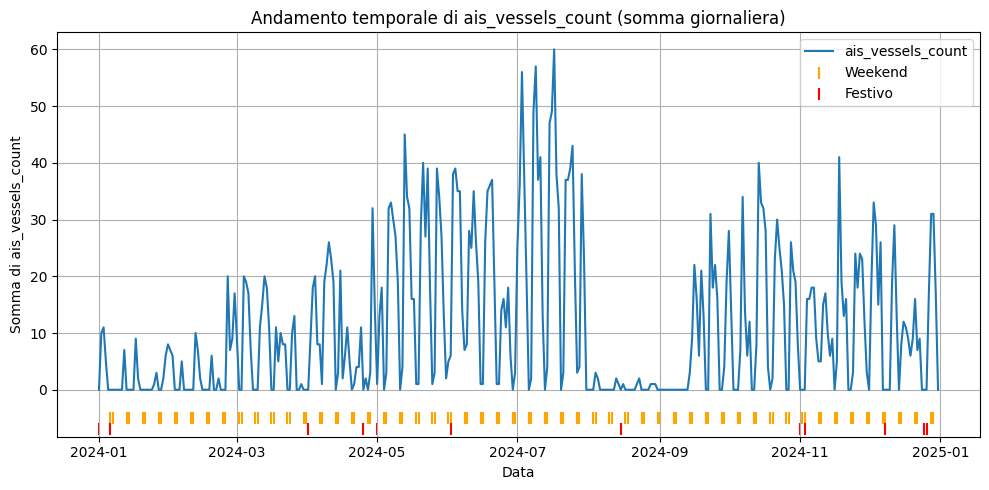

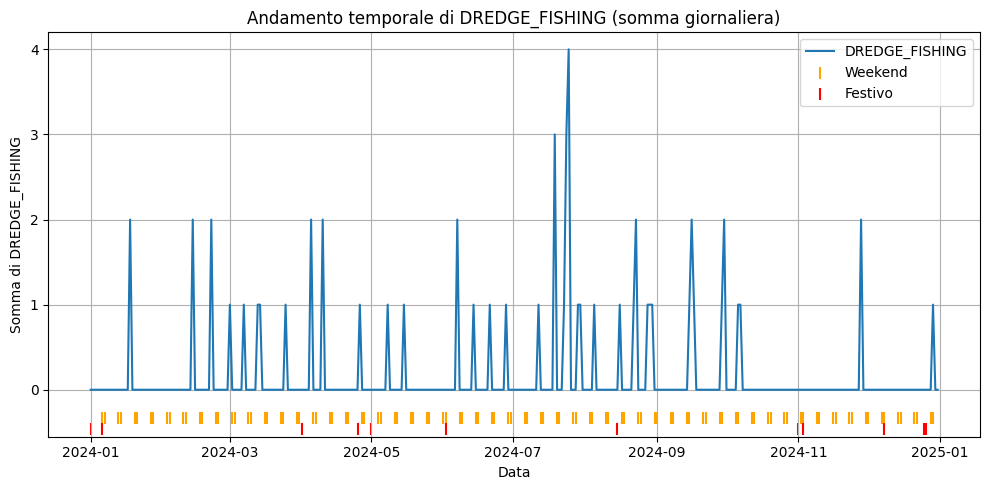

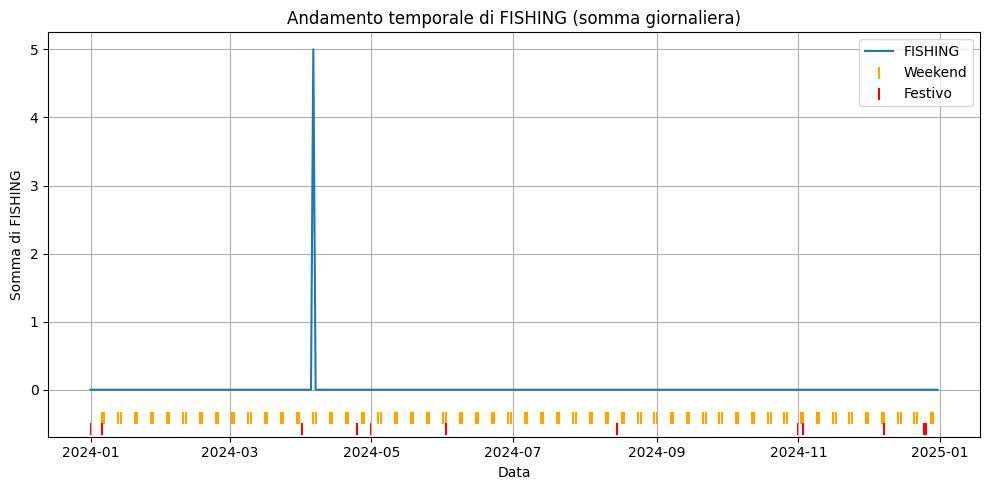

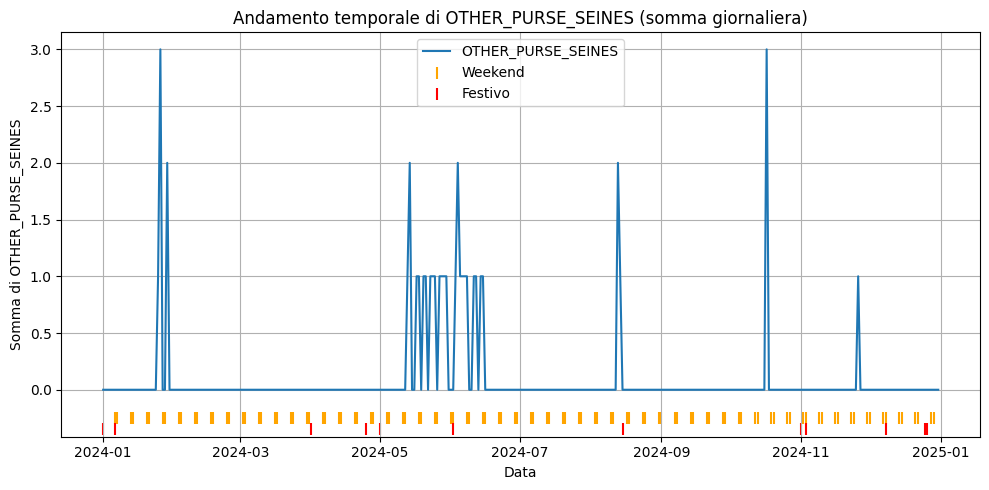

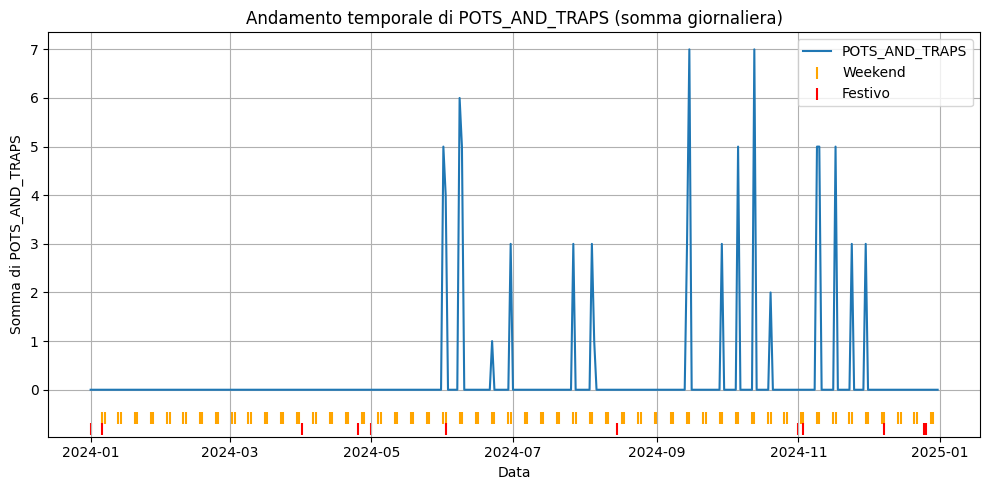

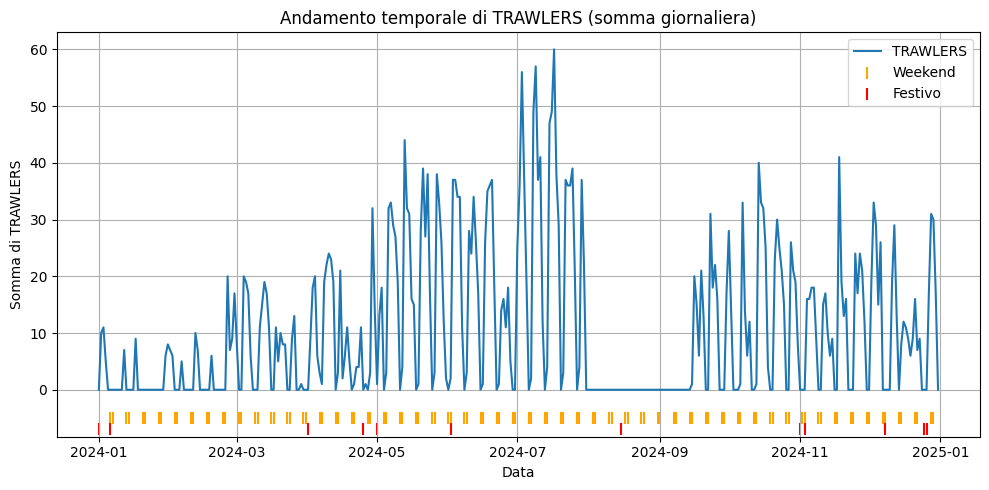

In [16]:
vessel_vars = [ 'sar_vessels_count', 'ais_vessels_count',
       'DREDGE_FISHING', 'FISHING', 'OTHER_PURSE_SEINES', 'POTS_AND_TRAPS',
       'TRAWLERS']  

for vessel_var in vessel_vars:
    # somma giornaliera
    df_bgc = cpr_gfw.groupby('date', as_index=False)[vessel_var].sum()
    # aggiungo info weekend/festivi
    df_plot = df_bgc.merge(date_flags, on='date', how='left')
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # linea principale
    ax.plot(df_plot['date'], df_plot[vessel_var], label=vessel_var)
    ax.set_xlabel('Data')
    ax.set_ylabel(f'Somma di {vessel_var}')
    ax.set_title(f'Andamento temporale di {vessel_var} (somma giornaliera)')
    ax.grid(True)

    # prendo i limiti attuali
    ymin, ymax = ax.get_ylim()
    span = ymax - ymin if ymax > ymin else 1.0

    # livelli leggermente sotto la serie per i marker
    y_weekend = ymin - 0.03 * span
    y_holiday = ymin - 0.06 * span

    # aggiusto il limite inferiore per farli vedere
    ax.set_ylim(y_holiday - 0.02 * span, ymax)

    # weekend: piccoli segmenti verticali (marker '|')
    weekend_dates = df_plot.loc[df_plot['is_weekend'], 'date']
    ax.scatter(
        weekend_dates,
        np.full(len(weekend_dates), y_weekend),
        marker='|',
        color='orange',
        s=80,
        label='Weekend'
    )

    # festività: piccoli segmenti verticali (marker '|')
    holiday_dates = df_plot.loc[df_plot['is_holiday'], 'date']
    ax.scatter(
        holiday_dates,
        np.full(len(holiday_dates), y_holiday),
        marker='|',
        color='red',
        s=80,
        label='Festivo'
    )

    # legenda (evito doppioni)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())

    plt.tight_layout()
    plt.show()


In [17]:
print("Medie delle variabili di vessel count nei giorni festivi:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_holiday'] == True
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni NON festivi:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_holiday'] == False
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei weekend:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_weekend'] == True
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni infrasettimanali:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['is_weekend'] == False
    ][vessel_var].mean()
    )

print("\nMedie delle variabili di vessel count nei giorni di blocco pesca:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['fishing_block'] == True
    ][vessel_var].mean()
    )


print("\nMedie delle variabili di vessel count nei giorni senza blocco pesca:")
for vessel_var in vessel_vars:
    print(vessel_var,
    cpr_gfw[
        cpr_gfw['fishing_block'] == False
    ][vessel_var].mean()
    )



Medie delle variabili di vessel count nei giorni festivi:
sar_vessels_count 0.2857142857142857
ais_vessels_count 0.011904761904761904
DREDGE_FISHING 0.0
FISHING 0.0
OTHER_PURSE_SEINES 0.0
POTS_AND_TRAPS 0.006802721088435374
TRAWLERS 0.00510204081632653

Medie delle variabili di vessel count nei giorni NON festivi:
sar_vessels_count 0.14043583535108958
ais_vessels_count 0.2322149198662516
DREDGE_FISHING 0.003286060186786579
FISHING 0.0002882508935777701
OTHER_PURSE_SEINES 0.0021907067911910525
POTS_AND_TRAPS 0.004323763403666551
TRAWLERS 0.22212613859102964

Medie delle variabili di vessel count nei weekend:
sar_vessels_count 0.24725274725274726
ais_vessels_count 0.044740973312401885
DREDGE_FISHING 0.0007849293563579278
FISHING 0.0009811616954474097
OTHER_PURSE_SEINES 0.0007849293563579278
POTS_AND_TRAPS 0.015306122448979591
TRAWLERS 0.026883830455259026

Medie delle variabili di vessel count nei giorni infrasettimanali:
sar_vessels_count 0.10468920392584515
ais_vessels_count 0.29654151

In [18]:
cpr_gfw.head()

,date,is_holiday,holiday_name,is_weekend,fishing_block,latitude,longitude,chl,thetao,sar_vessels_count,ais_vessels_count,DREDGE_FISHING,FISHING,OTHER_PURSE_SEINES,POTS_AND_TRAPS,TRAWLERS
0,2024-01-01,True,New Year's Day,False,False,45.479168,13.166667,0.432612,13.304394,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-02,False,None,False,False,45.479168,13.166667,0.409951,13.248711,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-03,False,None,False,False,45.479168,13.166667,0.387921,13.063446,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-04,False,None,False,False,45.479168,13.166667,0.367288,12.772483,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-05,False,None,False,False,45.479168,13.166667,0.347252,13.004619,0.0,0.0,0.0,0.0,0.0,0.0,0.0
